In [1]:
import sys
from pathlib import Path
notebook_dir = Path().resolve()
ROOT = notebook_dir.parent
sys.path.append(str(ROOT))

from torch_geometric.datasets import Amazon
from src.plotting import display_result_tables,plot_accs_bar_with_singe_embs,plot_loss_vs_acc_per_encoder,intra_inter_similarities_sampled,plot_intra_inter,plot_avgAcc_vs_singe_embs, plot_loss_per_encoder
import torch

dataset = Amazon(root='/Users/emely/Uni/Thesis/Thesis/data', name='Computers')
data = dataset[0]

all_losses=torch.load(Path("/Users/emely/Uni/Thesis/Thesis/amazon/results/loss_histories.pt"))
other_accs=torch.load(Path("/Users/emely/Uni/Thesis/Thesis/amazon/results/best_acc_node_pos.pt"))
all_embeddings = torch.load(Path("/Users/emely/Uni/Thesis/Thesis/amazon/results/embeddings.pt"))
accs = torch.load(Path("/Users/emely/Uni/Thesis/Thesis/amazon/results/best_accs.pt"))
svm_results = torch.load(Path("/Users/emely/Uni/Thesis/Thesis/amazon/results/svm_results.pt"))
svm_results_node_pos = torch.load(Path("/Users/emely/Uni/Thesis/Thesis/amazon/results/svm_results_node_pos.pt"))

encoders = ['gcn', 'sage', 'gat', 'gin']
modes= ['Rand-Rewire', 'Rand-Aug', 'DP-Rewire', 'DP-Aug']

In [2]:
display_result_tables(accs, svm_results, other_accs, svm_results_node_pos)


## MLP Results

,Mode,gcn,sage,gat,gin
0,Rand-Aug,0.904 ± 0.006,0.893 ± 0.004,0.903 ± 0.002,0.849 ± 0.007
1,Rand-Rewire,0.911 ± 0.004,0.887 ± 0.006,0.895 ± 0.015,0.713 ± 0.067
2,DP-Rewire,0.917 ± 0.005,0.893 ± 0.003,0.909 ± 0.008,0.764 ± 0.075
3,DP-Aug,0.895 ± 0.005,0.878 ± 0.006,0.899 ± 0.004,0.833 ± 0.006


## SVM Results

,Mode,gcn,sage,gat,gin
0,Rand-Aug,0.861 ± 0.002,0.853 ± 0.002,0.868 ± 0.004,0.796 ± 0.013
1,Rand-Rewire,0.857 ± 0.012,0.873 ± 0.006,0.829 ± 0.035,0.624 ± 0.072
2,DP-Rewire,0.887 ± 0.004,0.872 ± 0.004,0.877 ± 0.015,0.681 ± 0.090
3,DP-Aug,0.859 ± 0.004,0.847 ± 0.008,0.871 ± 0.005,0.776 ± 0.008


## Node2Vec & PosEnc & Original Features – MLP + SVM

,Embedding,MLP Test Accuracy,SVM Test Accuracy
0,Node2Vec,0.900,0.852
1,LaplacianPosEnc,0.847,0.831
2,OriginalFeatures,0.847,0.831


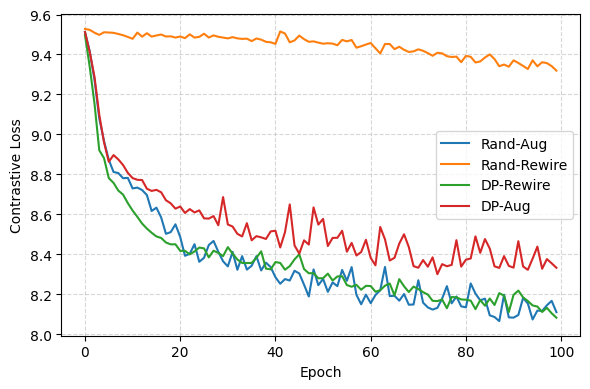

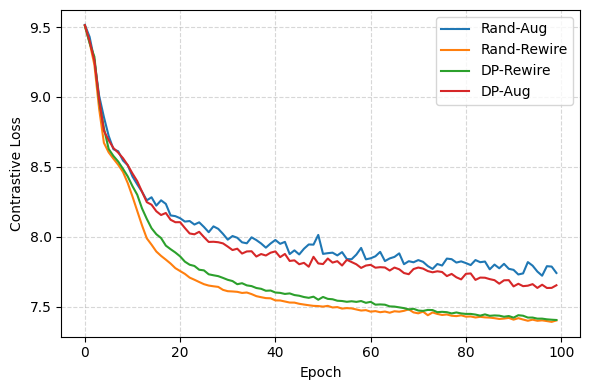

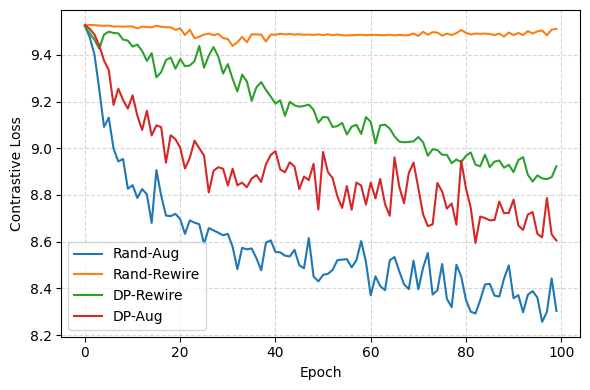

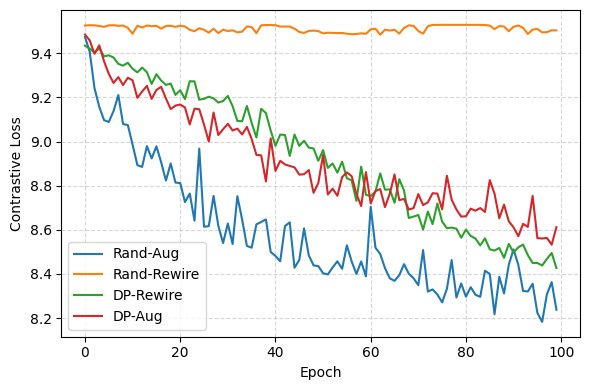

In [3]:
plot_loss_per_encoder(all_losses)

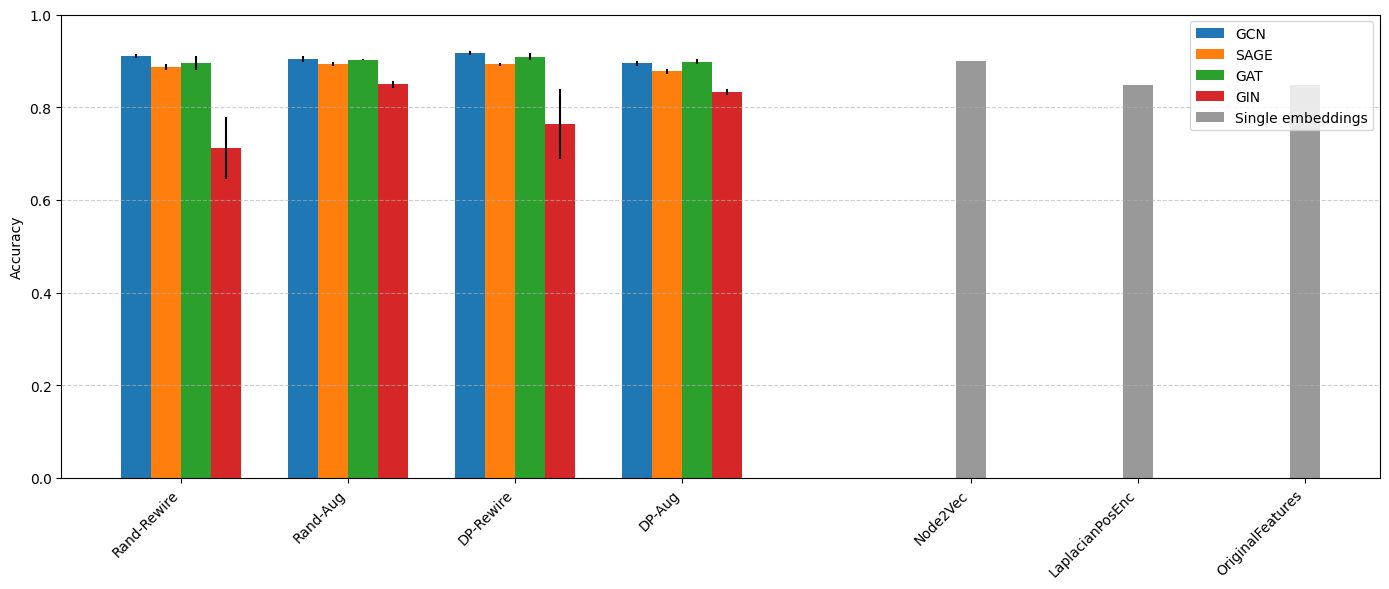

In [4]:
plot_accs_bar_with_singe_embs(other_accs,modes,encoders,accs)
 

/Users/emely/Uni/Thesis/Thesis/src/plotting.py:183: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  loss_curve = torch.tensor(all_losses[mode][enc])


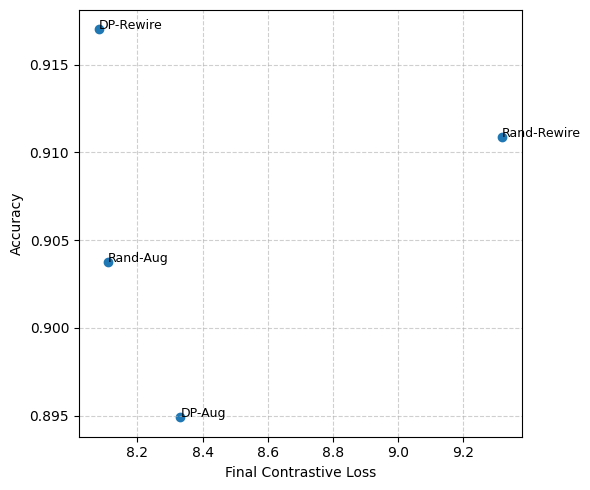

/Users/emely/Uni/Thesis/Thesis/src/plotting.py:183: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  loss_curve = torch.tensor(all_losses[mode][enc])


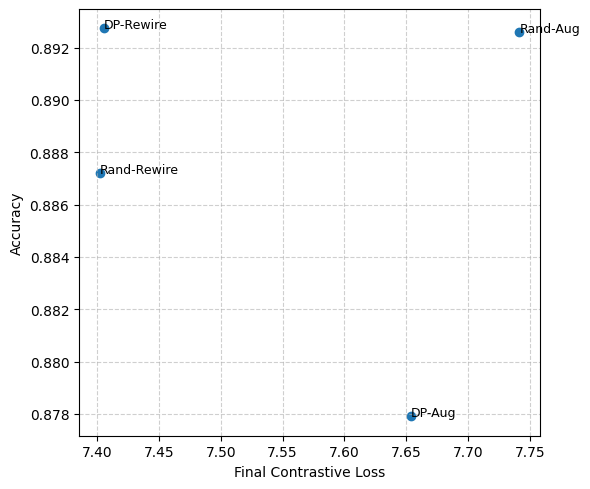

/Users/emely/Uni/Thesis/Thesis/src/plotting.py:183: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  loss_curve = torch.tensor(all_losses[mode][enc])


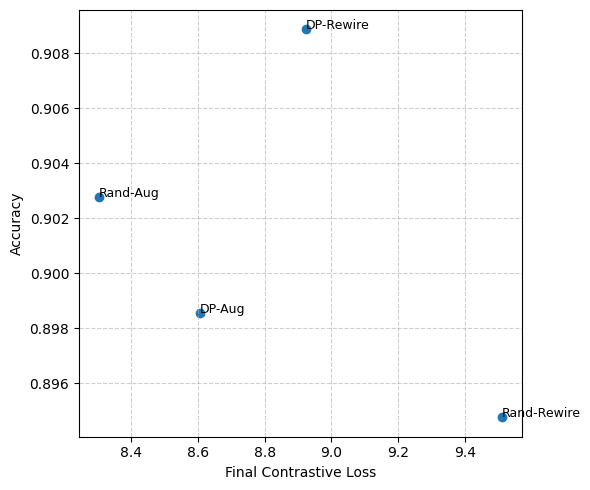

/Users/emely/Uni/Thesis/Thesis/src/plotting.py:183: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  loss_curve = torch.tensor(all_losses[mode][enc])


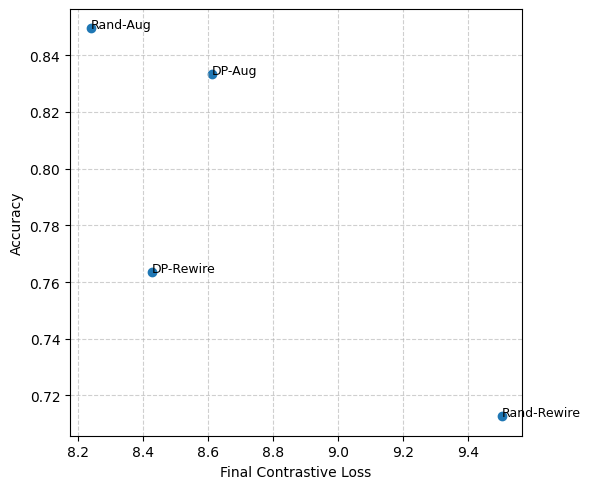

In [5]:
plot_loss_vs_acc_per_encoder(encoders,all_losses,accs)


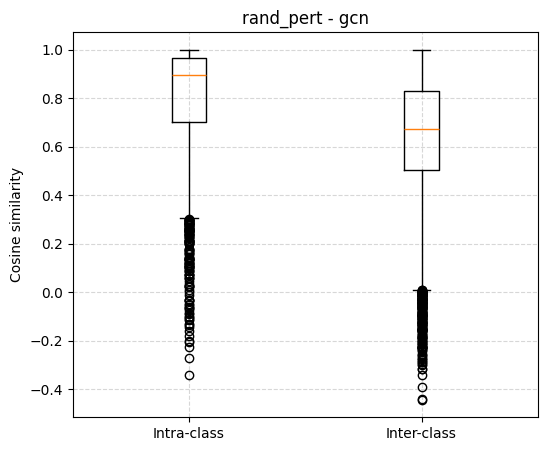

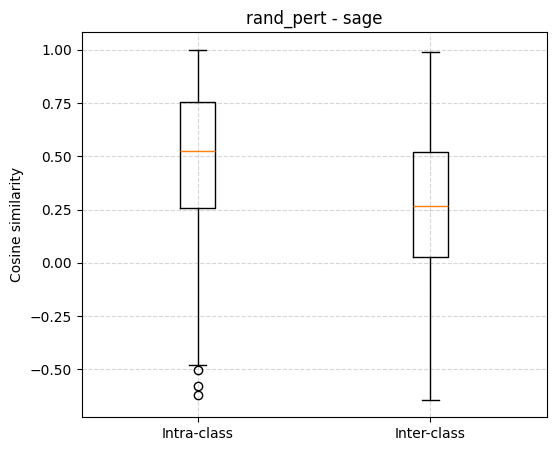

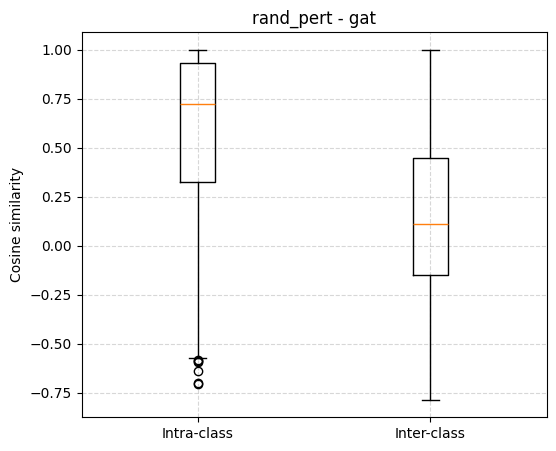

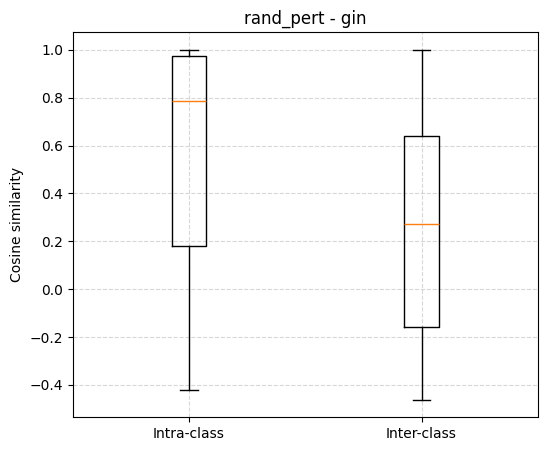

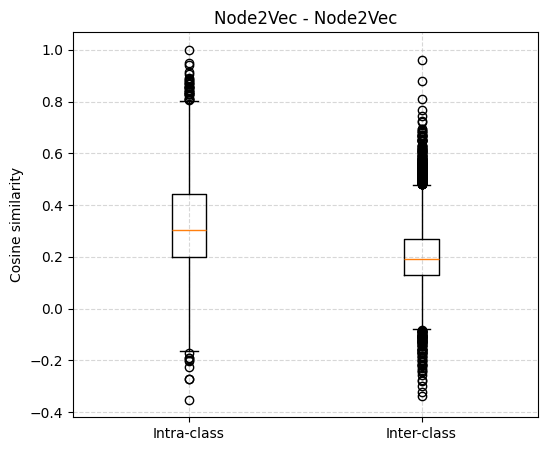

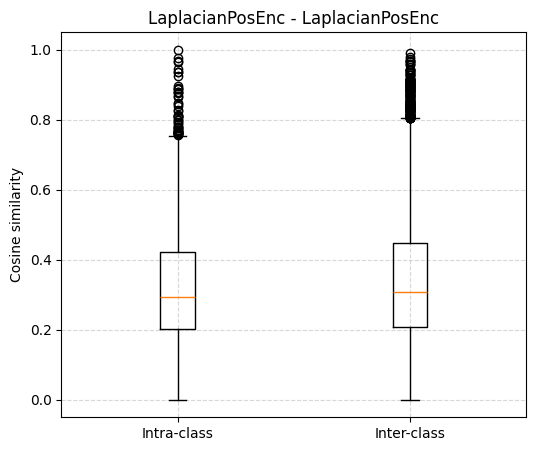

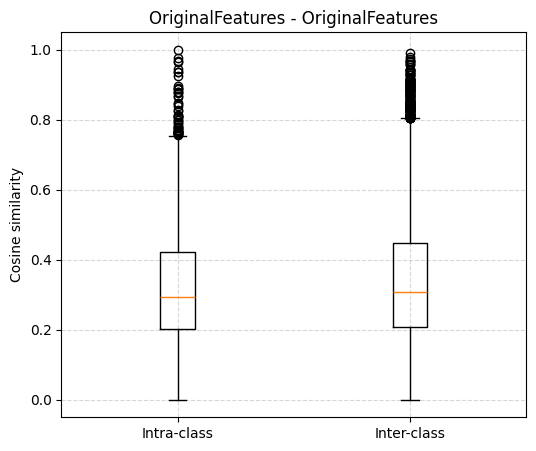

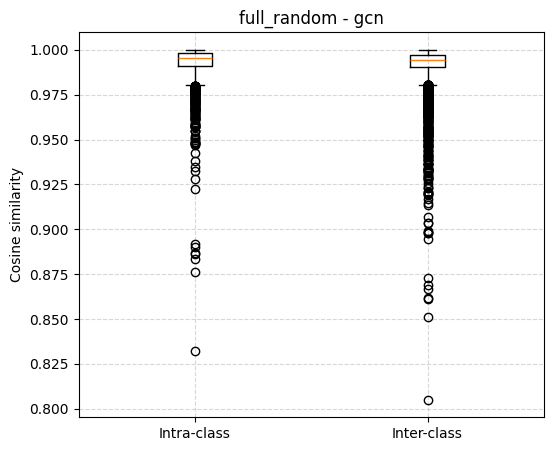

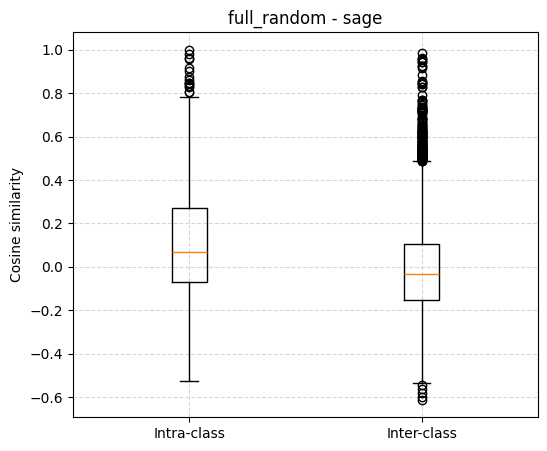

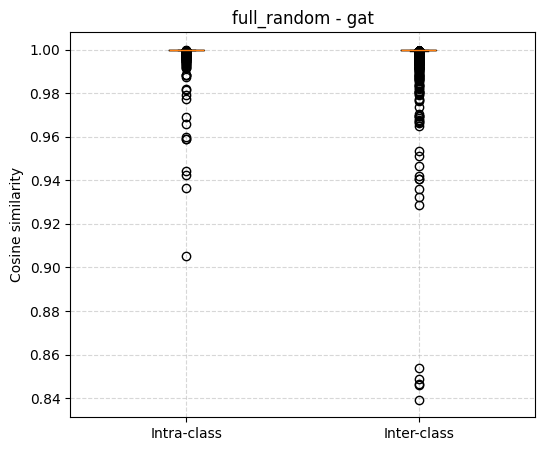

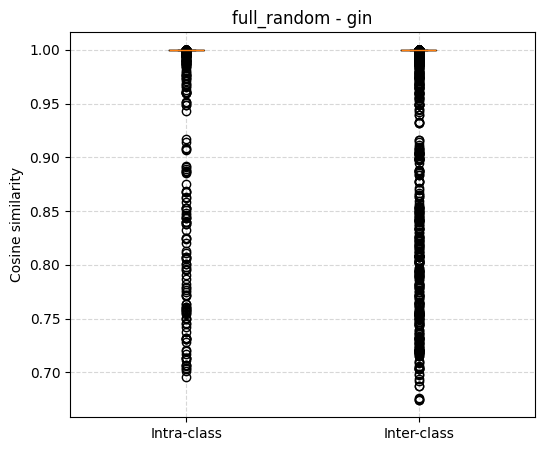

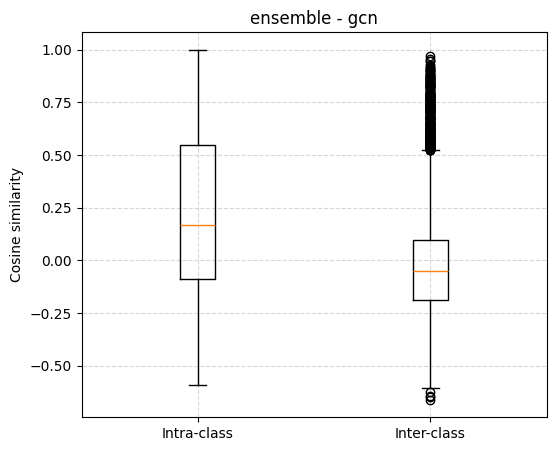

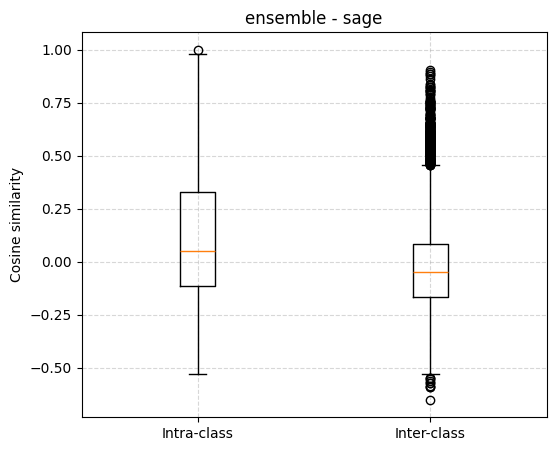

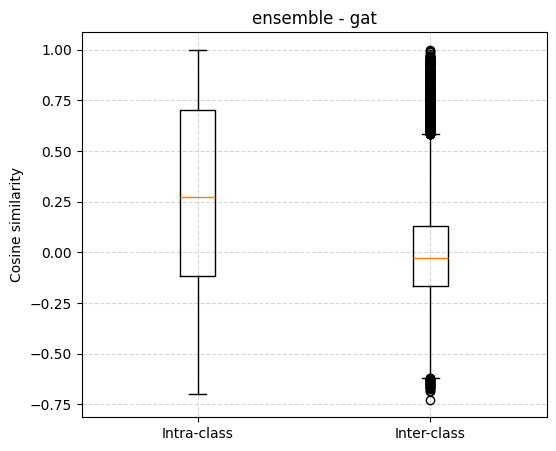

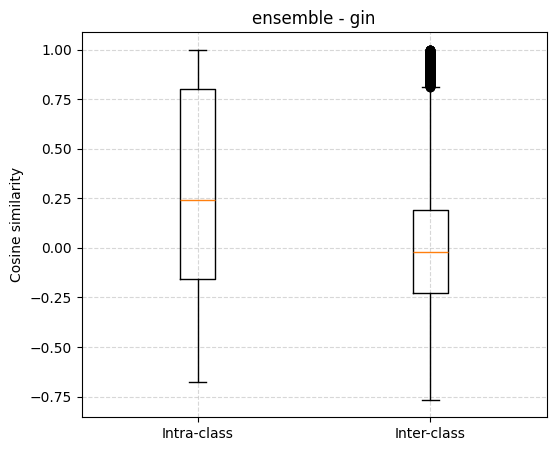

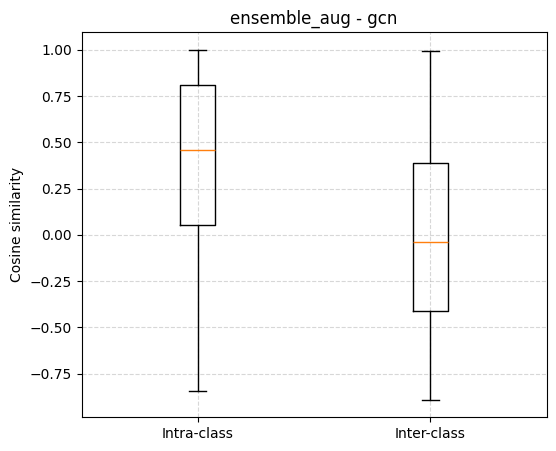

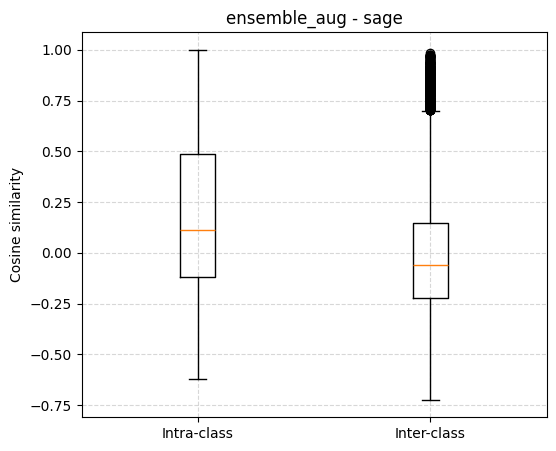

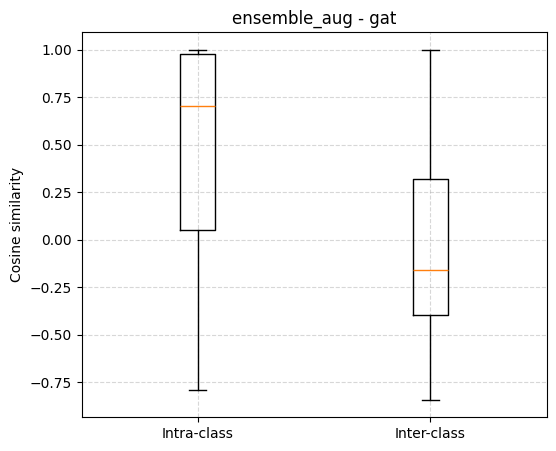

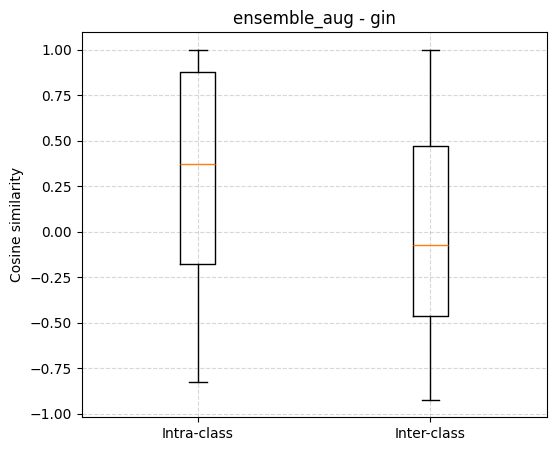

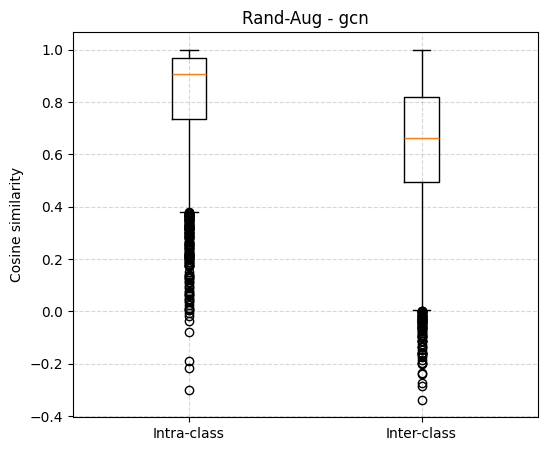

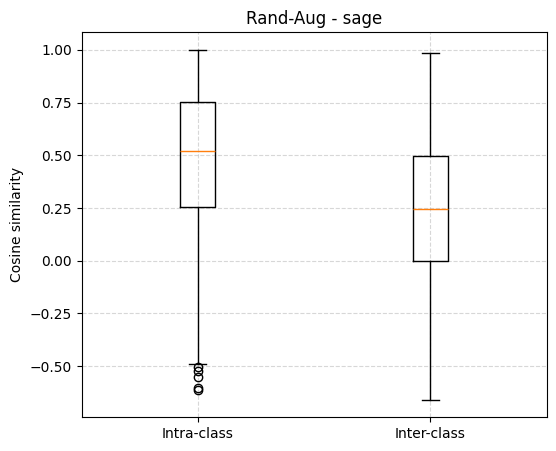

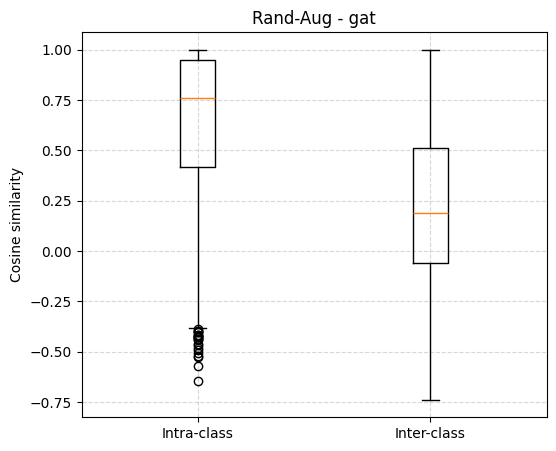

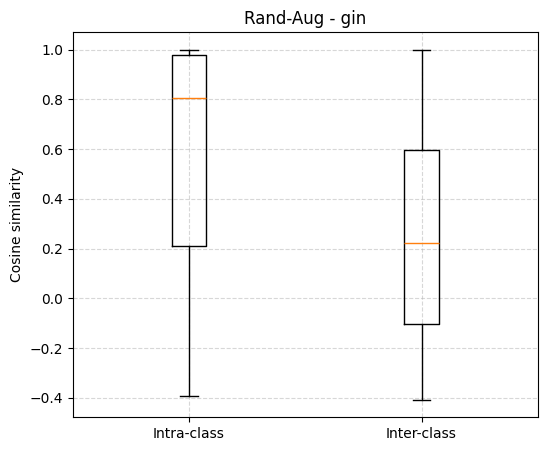

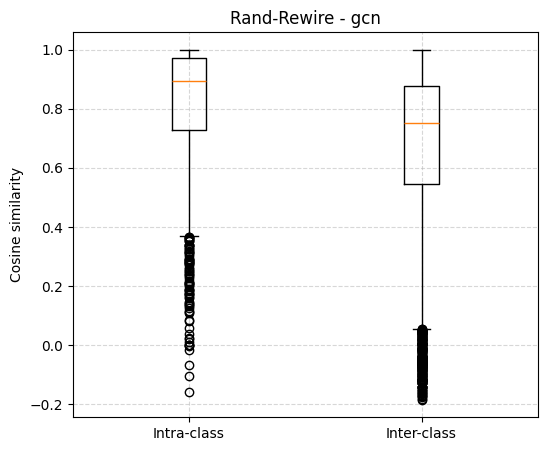

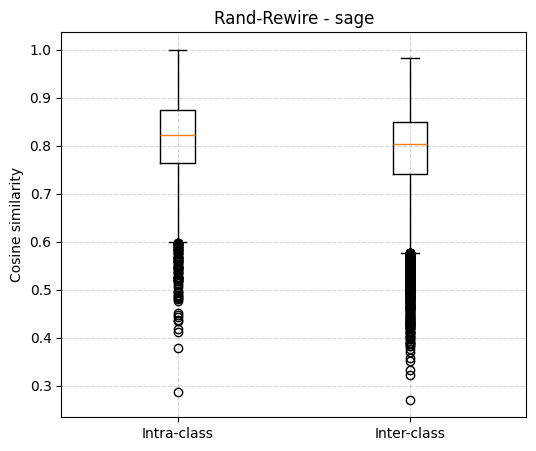

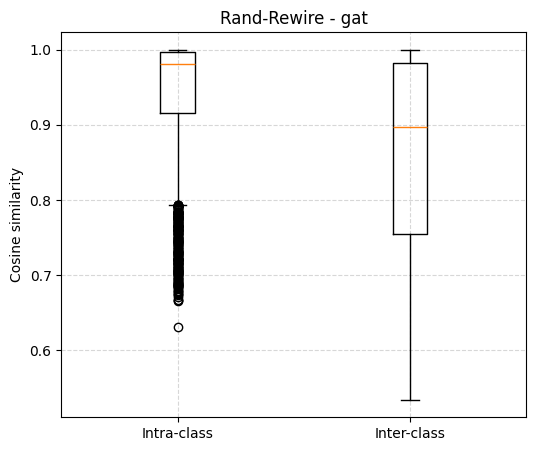

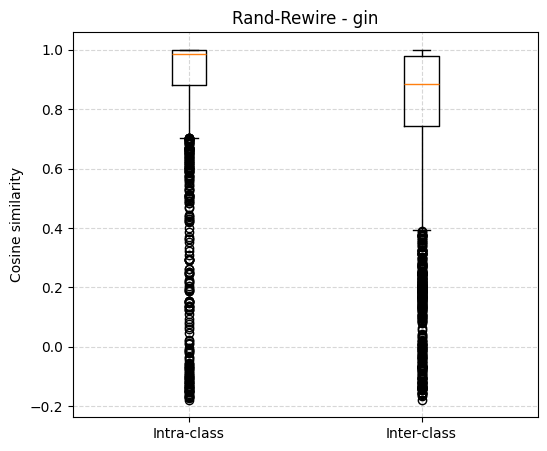

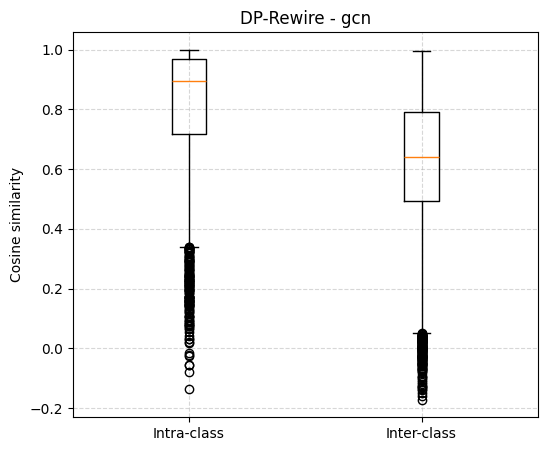

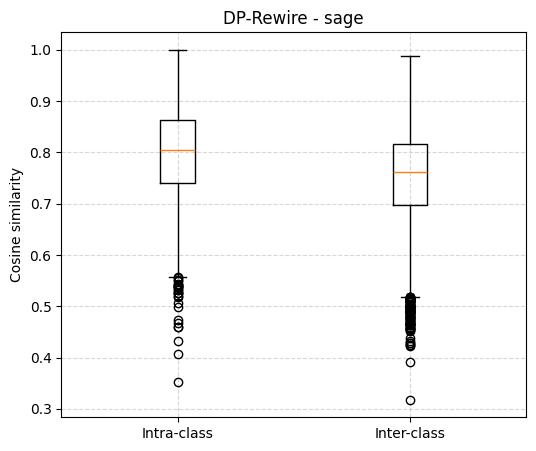

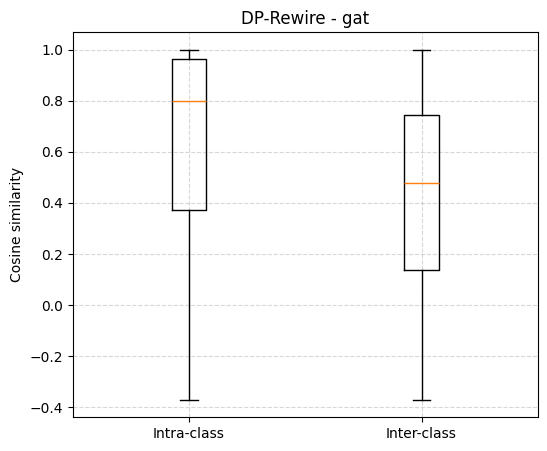

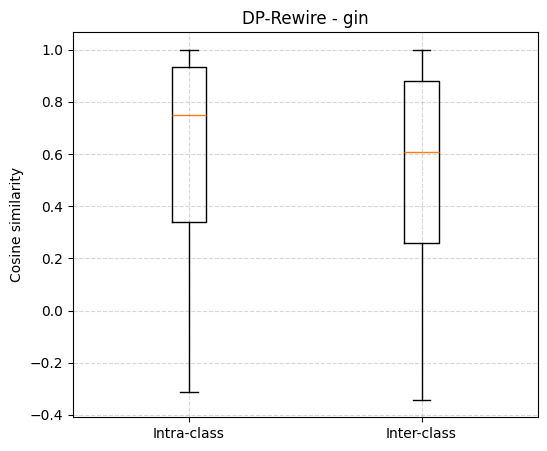

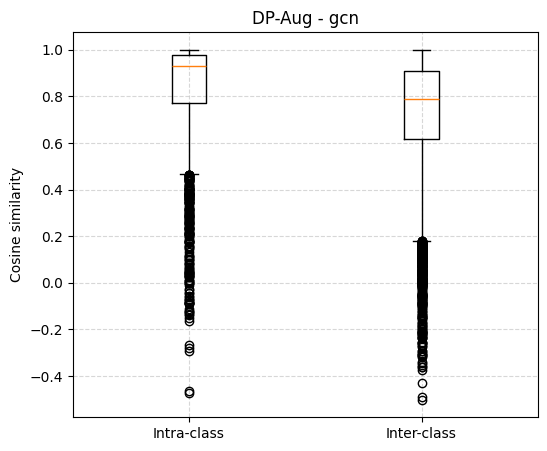

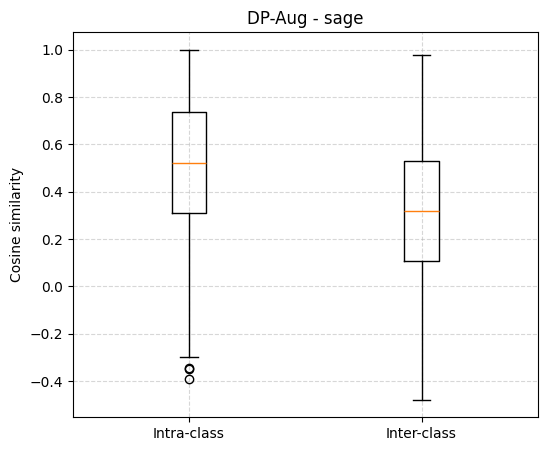

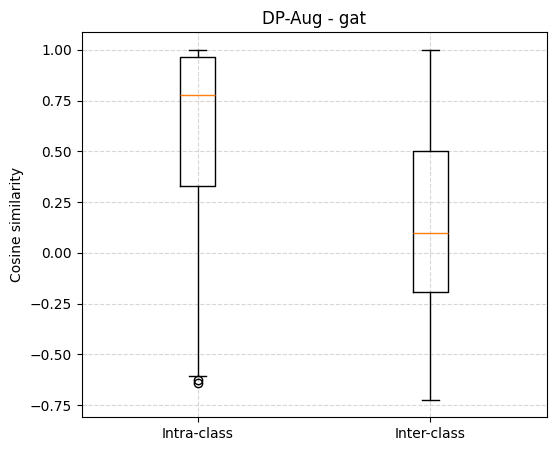

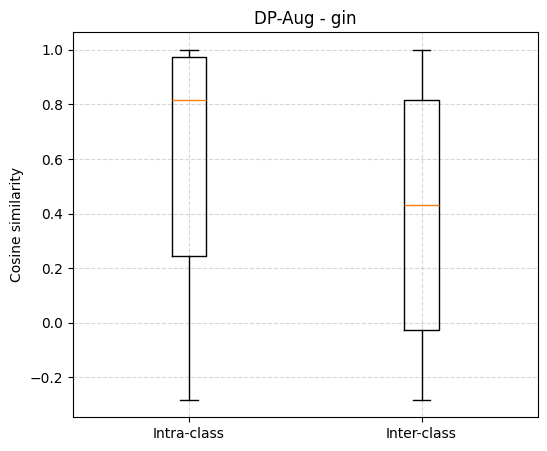

In [6]:
for mode_name, embeddings_per_encoder in all_embeddings.items():
    for encoder_name, emb in embeddings_per_encoder.items():
        intra, inter = intra_inter_similarities_sampled(emb, data.y, num_samples=10000)
        plot_intra_inter(intra, inter, f"{mode_name} - {encoder_name}")


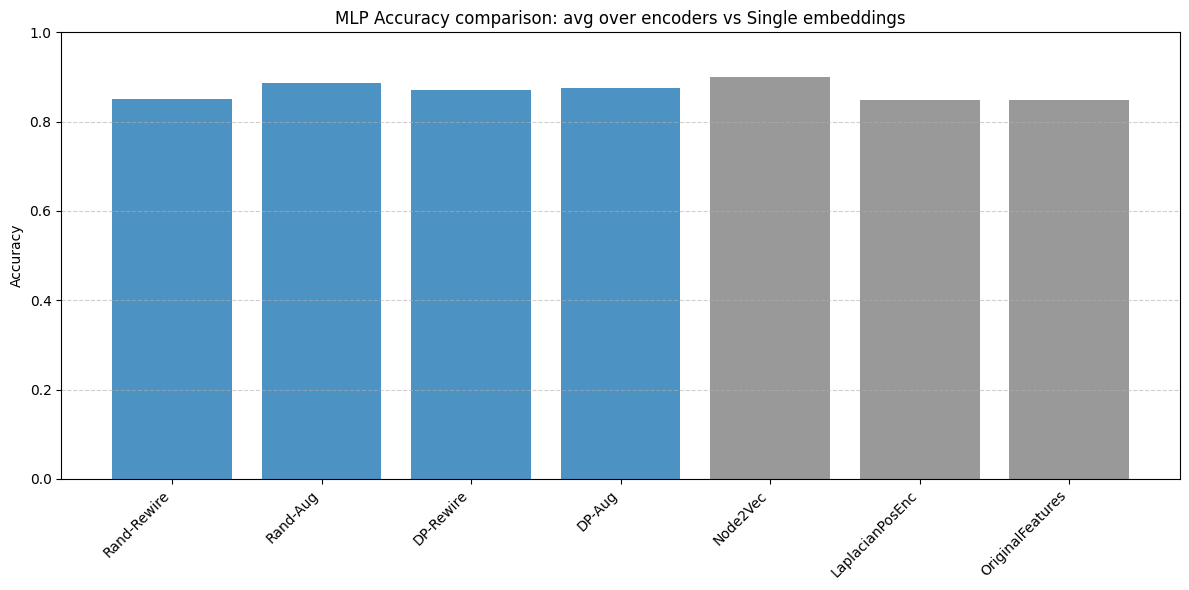

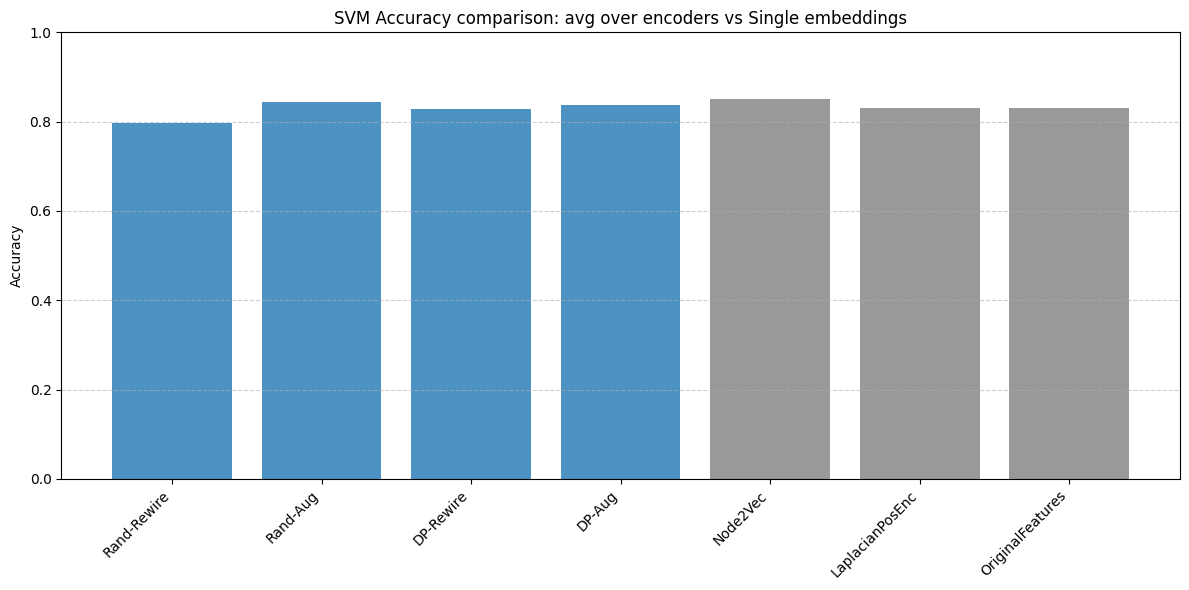

In [7]:
plot_avgAcc_vs_singe_embs(modes,other_accs,accs,"MLP Accuracy comparison: avg over encoders vs Single embeddings")
plot_avgAcc_vs_singe_embs(modes,svm_results_node_pos,svm_results,"SVM Accuracy comparison: avg over encoders vs Single embeddings")